# 03 · Modelo Tabular (baseline)

**Objetivo:** Establecer un modelo baseline usando únicamente los metadatos clínicos (edad, sexo, localización) sin información visual.

**Datos de entrada:** `../data/raw/HAM10000_metadata.csv`

**Resultado esperado:** Modelo guardado en `../models/tabular_model.h5` con ~69% de accuracy en test.

**Arquitectura:** Red densa (Sequential) — 3 capas Dense con Dropout.

## Carga de datos y preprocesado

El preprocesado (split 70/15/15, imputación, estandarización) está centralizado en `utils.py`.
Las decisiones de diseño están documentadas en `02_data_preparation.ipynb`.


Tabular — Train: 7010 | Val: 1502 | Test: 1503
Clases: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                576       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 8)                 264       
                                                                 
 dense_2 (Dense)             (None, 7)                 63        
                                                                 
Total params: 903 (3.53 KB)
Trainable params: 903 (3.53 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/100


220/220 [==============================] 

c:\Users\rammu\anaconda3\envs\deep_learning\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


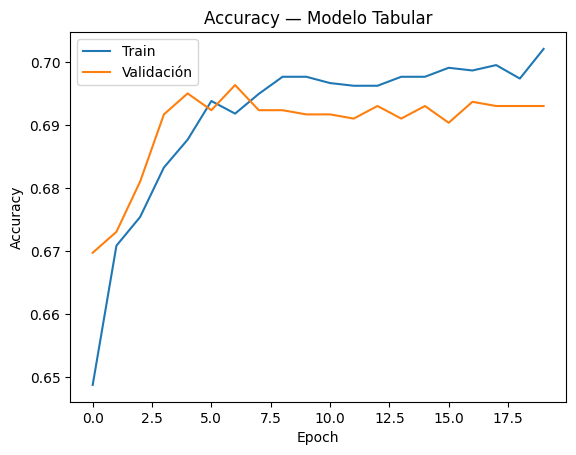

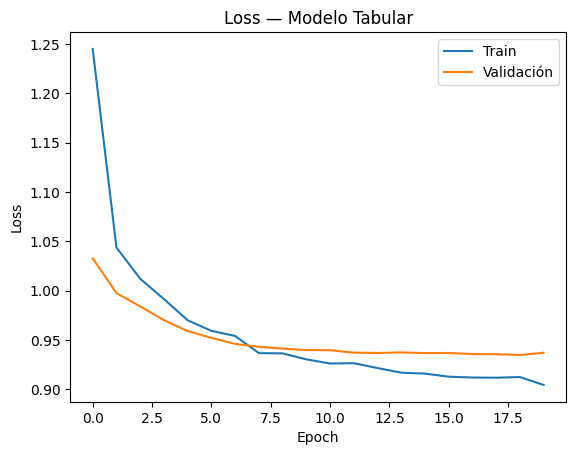

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ── Carga y preprocesado centralizados en utils.py ────────────────────────────
from utils import get_tabular_splits

X_train, X_val, X_test, y_train, y_val, y_test, label_encoder = get_tabular_splits()
num_classes = y_train.shape[1]

# ── Arquitectura ──────────────────────────────────────────────────────────────
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ── Entrenamiento ─────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss', patience=10, min_delta=0.005, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

# ── Evaluación ────────────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
model.save('../models/tabular_model.h5')

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Accuracy — Modelo Tabular')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Loss — Modelo Tabular')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

## Evaluación detallada por clase

El accuracy global no es suficiente en diagnóstico médico. Aquí vemos cuánto acierta el modelo en **cada tipo de lesión** por separado, y lo comparamos con el **baseline ZeroR** (lo que conseguiría un modelo que predice siempre la clase más frecuente, sin aprender nada).

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Predicciones sobre el conjunto de test
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Baseline ZeroR: accuracy de predecir siempre la clase más frecuente
from collections import Counter
most_common = Counter(y_true).most_common(1)[0][1]
baseline = most_common / len(y_true)
print(f'Baseline ZeroR (predecir siempre la clase más frecuente): {baseline:.2%}')
print(f'Accuracy del modelo: {(y_pred == y_true).mean():.2%}')
print(f'Mejora sobre baseline: {(y_pred == y_true).mean() - baseline:+.2%}')

# Desglose por clase
print('Resultados por clase diagnóstica:')
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

47/47 [==============================] - 0s 631us/step
Baseline ZeroR (predecir siempre la clase más frecuente): 66.93%
Accuracy del modelo: 70.46%
Mejora sobre baseline: +3.53%
Resultados por clase diagnóstica:
              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.00      0.00      0.00        77
         bkl       0.39      0.45      0.42       165
          df       0.00      0.00      0.00        17
         mel       0.38      0.02      0.03       167
          nv       0.75      0.98      0.85      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.70      1503
   macro avg       0.22      0.21      0.19      1503
weighted avg       0.59      0.70      0.62      1503



c:\Users\rammu\anaconda3\envs\deep_learning\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rammu\anaconda3\envs\deep_learning\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rammu\anaconda3\envs\deep_learning\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

: 

## Curvas ROC y matriz de confusión

La **curva ROC** mide cómo de bien el modelo separa cada clase del resto. El **AUC** (área bajo la curva) resume esto en un número: 1.0 = perfecto, 0.5 = aleatorio (no aprende nada).

En diagnóstico médico el AUC del **melanoma** (`mel`) es especialmente crítico: un falso negativo (diagnosticar como benigno algo maligno) tiene consecuencias graves.

La **matriz de confusión** muestra dónde se equivoca el modelo: qué clases confunde entre sí.

In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

# ── Curvas ROC por clase ──────────────────────────────────────────────────────
y_true_bin = label_binarize(y_true, classes=range(len(label_encoder.classes_)))

fig, ax = plt.subplots(figsize=(9, 6))
for i, (clase, color) in enumerate(zip(label_encoder.classes_, plt.cm.tab10.colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{clase} (AUC = {auc(fpr, tpr):.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC = 0.50)')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Sensibilidad (Recall / TPR)')
ax.set_title('Curvas ROC por clase — Modelo Tabular')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr', average='macro')
print(f'AUC macro (promedio One-vs-Rest): {macro_auc:.4f}')

# ── Matriz de confusión ───────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión — Modelo Tabular')
plt.tight_layout()
plt.show()

# Conclusiones del modelo tabular

Vemos que este modelo es muy limitado, ya que su precisión es aproximadamente de 0.69%. Esto es de esperar, ya que utiliza sólo metadatos de la lesión (la localización de la lesión, edad del paciente y su sexo), no la imagen real. Sin embargo, podría ser un buen punto de entrada para plantear un modelo Early o Late fusion donde utilicemos estos datos con un peso menor para ayudar a nuestras redes a entender mejor los datos de las imágenes. Además, nos sirve para comparar con los modelos basados sólo en imágenes y observar su efectividad
Además, como podemos ver en los gráficos, a partir de la epoch 10 conseguimos una efectividad bastante estable, por lo que probablemente limitar las epoch a 10 habría sido un buen movimiento (no lo hacemos porque al ser sólo metadatos, nuestras cpus y gpus ) hacen este trabajo con relativa facilidad y no nos supone mucho más tiempo)